In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (891, 12)
Test shape: (418, 11)


In [5]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# Điền tuổi bị thiếu bằng median
train_df["Age"] = train_df["Age"].fillna(train_df["Age"].median())
test_df["Age"] = test_df["Age"].fillna(train_df["Age"].median())

# Điền Embarked bằng giá trị xuất hiện nhiều nhất
train_df["Embarked"] = train_df["Embarked"].fillna(
    train_df["Embarked"].mode()[0]
)

test_df["Embarked"] = test_df["Embarked"].fillna(
    train_df["Embarked"].mode()[0]
)

# Test có thể thiếu Fare
test_df["Fare"] = test_df["Fare"].fillna(train_df["Fare"].median())

print("Missing values after cleaning:")
print(train_df.isnull().sum())

Missing values after cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


In [8]:
print(train_df["Survived"].value_counts())

survival_rate = train_df["Survived"].mean() * 100
print(f"Survival rate: {survival_rate:.2f}%")

Survived
0    549
1    342
Name: count, dtype: int64
Survival rate: 38.38%


In [9]:
print(
    train_df.groupby("Sex")["Survived"].mean()
)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


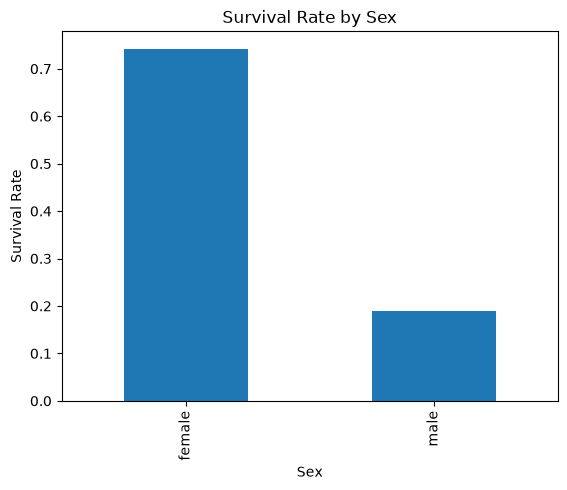

In [10]:
train_df.groupby("Sex")["Survived"].mean().plot(kind="bar")

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.show()

In [11]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = train_df[features]
y = train_df["Survived"]

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [12]:
X = pd.get_dummies(
    X,
    columns=["Sex", "Embarked"],
    drop_first=True
)

X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: (712, 8)
Validation: (179, 8)


In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [15]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 81.56%


In [16]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_val, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179

Confusion Matrix:
[[96 14]
 [19 50]]


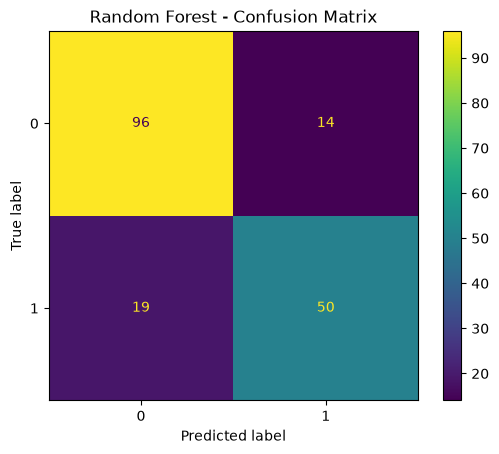

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [18]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_val)

logistic_accuracy = accuracy_score(
    y_val,
    logistic_pred
)

print(
    f"Logistic Regression Accuracy: "
    f"{logistic_accuracy * 100:.2f}%"
)

print(
    f"Random Forest Accuracy: "
    f"{accuracy * 100:.2f}%"
)

Logistic Regression Accuracy: 80.45%
Random Forest Accuracy: 81.56%


In [19]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,Fare,0.278484
5,Sex_male,0.263240
1,Age,0.252361
0,Pclass,0.079478
2,SibSp,0.053489
3,Parch,0.041017
7,Embarked_S,0.023194
6,Embarked_Q,0.008736


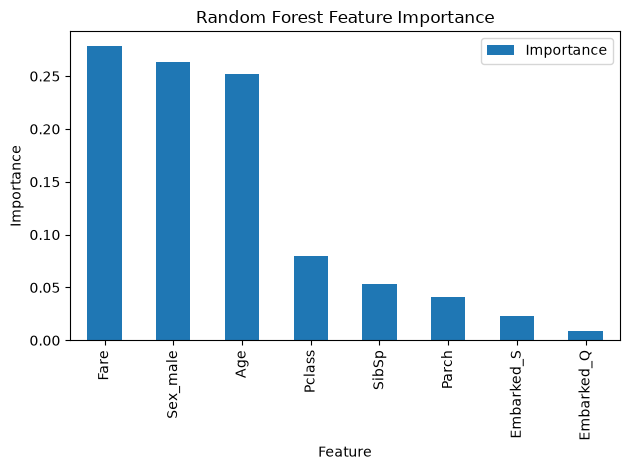

In [20]:
feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [21]:
X_test = test_df[features].copy()

X_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


In [22]:
X_test = pd.get_dummies(
    X_test,
    columns=["Sex", "Embarked"],
    drop_first=True
)

X_test.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,34.5,0,0,7.8292,True,True,False
1,3,47.0,1,0,7.0000,False,False,True
2,2,62.0,0,0,9.6875,True,True,False
3,3,27.0,0,0,8.6625,True,False,True
4,3,22.0,1,1,12.2875,False,False,True


In [23]:
X_test = X_test.reindex(
    columns=X.columns,
    fill_value=0
)

print(X_test.columns)

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='str')


In [24]:
X_test.isnull().sum()

Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

In [25]:
X_test["Age"] = X_test["Age"].fillna(train_df["Age"].median())
X_test["Fare"] = X_test["Fare"].fillna(train_df["Fare"].median())

In [26]:
X_test.isnull().sum()

Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

In [27]:
test_predictions = model.predict(X_test)

print(test_predictions[:20])

[0 0 0 1 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0]


In [28]:
print("Passengers in test set:", len(test_df))
print("Predictions:", len(test_predictions))

Passengers in test set: 418
Predictions: 418


In [29]:
submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_predictions
})

submission.head(10)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0
5,897,0
6,898,0
7,899,0
8,900,1
9,901,0


In [30]:
print(submission.shape)
print(submission["Survived"].value_counts())

(418, 2)
Survived
0    270
1    148
Name: count, dtype: int64


In [31]:
submission.to_csv(
    "../submission.csv",
    index=False
)

print("submission.csv created successfully!")

submission.csv created successfully!


In [32]:
train_v2 = train_df.copy()
test_v2 = test_df.copy()

In [33]:
train_v2["FamilySize"] = train_v2["SibSp"] + train_v2["Parch"] + 1
test_v2["FamilySize"] = test_v2["SibSp"] + test_v2["Parch"] + 1

In [34]:
train_v2["IsAlone"] = (train_v2["FamilySize"] == 1).astype(int)
test_v2["IsAlone"] = (test_v2["FamilySize"] == 1).astype(int)

In [35]:
train_v2["Title"] = train_v2["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()
test_v2["Title"] = test_v2["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()

print(train_v2["Title"].value_counts())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


In [36]:
common_titles = ["Mr", "Miss", "Mrs", "Master"]

train_v2["Title"] = train_v2["Title"].where(
    train_v2["Title"].isin(common_titles),
    "Rare"
)

test_v2["Title"] = test_v2["Title"].where(
    test_v2["Title"].isin(common_titles),
    "Rare"
)

In [37]:
features_v2 = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "Title"
]

X_v2 = train_v2[features_v2]
y_v2 = train_v2["Survived"]

In [38]:
X_v2 = pd.get_dummies(
    X_v2,
    columns=["Sex", "Embarked", "Title"],
    drop_first=True
)

X_v2.head()

,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,22.0,1,0,7.2500,2,0,True,False,True,False,True,False,False
1,1,38.0,1,0,71.2833,2,0,False,False,False,False,False,True,False
2,3,26.0,0,0,7.9250,1,1,False,False,True,True,False,False,False
3,1,35.0,1,0,53.1000,2,0,False,False,True,False,False,True,False
4,3,35.0,0,0,8.0500,1,1,True,False,True,False,True,False,False


In [39]:
from sklearn.model_selection import train_test_split

X_train_v2, X_val_v2, y_train_v2, y_val_v2 = train_test_split(
    X_v2,
    y_v2,
    test_size=0.2,
    random_state=42,
    stratify=y_v2
)

In [40]:
from sklearn.ensemble import RandomForestClassifier

model_v2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model_v2.fit(X_train_v2, y_train_v2)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [41]:
from sklearn.metrics import accuracy_score

pred_v2 = model_v2.predict(X_val_v2)

accuracy_v2 = accuracy_score(y_val_v2, pred_v2)

print(f"Random Forest V1: {accuracy * 100:.2f}%")
print(f"Random Forest V2: {accuracy_v2 * 100:.2f}%")

Random Forest V1: 81.56%
Random Forest V2: 83.24%


In [42]:
submission.to_csv(
    "../submission2.csv",
    index=False
)

print("submission.csv created successfully!")

submission.csv created successfully!


In [43]:
# Chuẩn bị test data cho V2
X_test_v2 = test_v2[features_v2].copy()

X_test_v2 = pd.get_dummies(
    X_test_v2,
    columns=["Sex", "Embarked", "Title"],
    drop_first=True
)

# Đồng bộ columns với dữ liệu V2 đã train
X_test_v2 = X_test_v2.reindex(
    columns=X_v2.columns,
    fill_value=0
)

print("Missing values:")
print(X_test_v2.isnull().sum())

Missing values:
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
FamilySize    0
IsAlone       0
Sex_male      0
Embarked_Q    0
Embarked_S    0
Title_Miss    0
Title_Mr      0
Title_Mrs     0
Title_Rare    0
dtype: int64


In [44]:
test_predictions_v2 = model_v2.predict(X_test_v2)

print(test_predictions_v2[:20])

[0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 0 1]


In [45]:
differences = (test_predictions != test_predictions_v2).sum()

print("Different predictions:", differences)

Different predictions: 51


In [46]:
submission_v2 = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_predictions_v2
})

submission_v2.to_csv(
    "../submission_v2.csv",
    index=False
)

print("Created submission_v2.csv")
print(submission_v2.head(10))

Created submission_v2.csv
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0


In [47]:
print("Shape:", submission_v2.shape)
print(submission_v2["Survived"].value_counts())

Shape: (418, 2)
Survived
0    269
1    149
Name: count, dtype: int64
